In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from kneed import KneeLocator

In [3]:
# Charger le fichier CSV
file_path = 'summary_by_3min.csv'  # Remplace par le chemin correct
df = pd.read_csv(file_path)

# Extraire la première colonne (supposée être un label)
labels = df.iloc[:, 0]  # Stocke les labels pour affichage ultérieur
df_numeric = df.drop(columns=df.columns[0])  # Supprime la colonne label pour l'analyse

In [4]:
statistics = df_numeric.describe().T[['mean', '25%', '50%', '75%', 'std']]
display(statistics)

,mean,25%,50%,75%,std
Vitesse Moyenne (km/h),81.175503,48.865268,92.442668,118.237784,39.405539
Vitesse Maximal (km/h),93.822991,75.081169,105.683066,122.965770,32.213569
Ecart type X (m/s²),0.435901,0.298026,0.367900,0.520041,0.197243
Ecart type Y (m/s²),0.417495,0.262316,0.324028,0.541494,0.227576
Stop Time (%),5.002157,0.000000,0.000000,0.000000,15.030313
Variation vitesse,1.787339,0.803027,1.234524,2.591911,1.286066


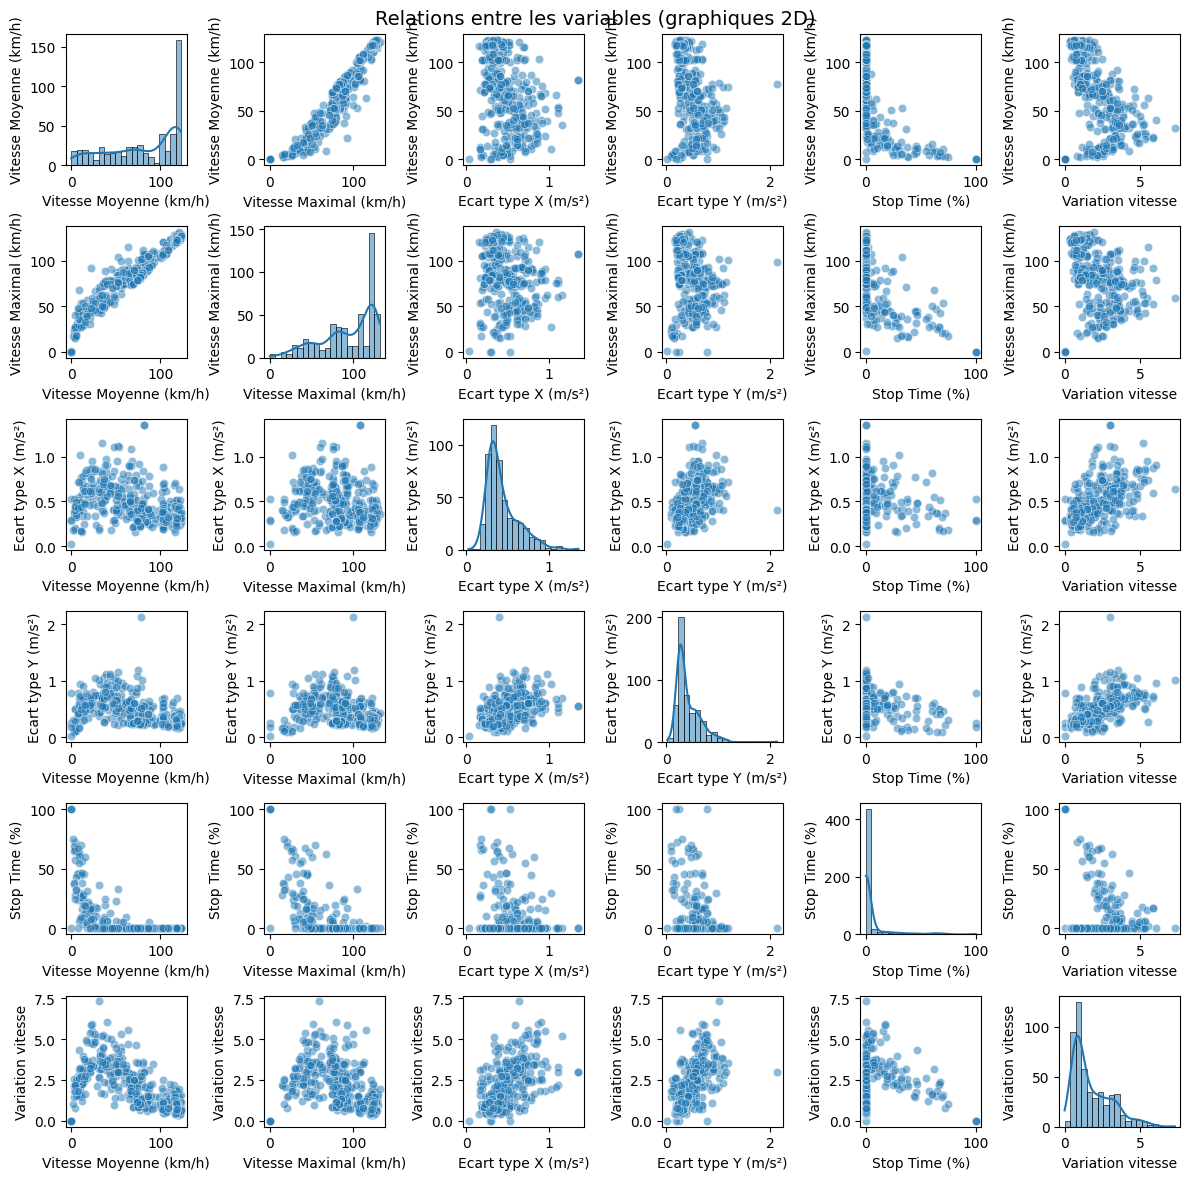

In [5]:
# Affichage des relations entre les variables avec des subplots 2D
variables = df_numeric.columns
num_vars = len(variables)
fig, axes = plt.subplots(num_vars, num_vars, figsize=(12, 12))

for i in range(num_vars):
    for j in range(num_vars):
        if i != j:
            sns.scatterplot(x=df_numeric.iloc[:, j], y=df_numeric.iloc[:, i], ax=axes[i, j], alpha=0.5)
        else:
            sns.histplot(df_numeric.iloc[:, i], kde=True, ax=axes[i, j], bins=20)
        
        axes[i, j].set_xlabel(variables[j])
        axes[i, j].set_ylabel(variables[i])

plt.suptitle("Relations entre les variables (graphiques 2D)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# 3. Normalisation des données
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

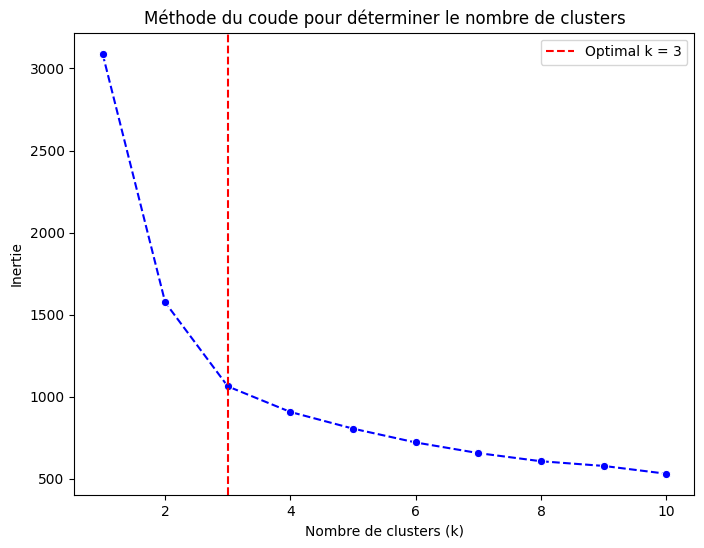

In [7]:

# 4. Détermination du nombre optimal de clusters (Méthode du coude)
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Trouver automatiquement le "coude"
knee_locator = KneeLocator(k_range, inertia, curve="convex", direction="decreasing")
optimal_k = knee_locator.elbow or 3  # Par défaut, prend 3 si pas de coude trouvé

# Afficher la courbe du coude
plt.figure(figsize=(8, 6))
sns.lineplot(x=k_range, y=inertia, marker="o", linestyle="--", color="b")
plt.axvline(optimal_k, color='r', linestyle='--', label=f"Optimal k = {optimal_k}")
plt.title("Méthode du coude pour déterminer le nombre de clusters")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.legend()
plt.show()

C:\Users\bertr\AppData\Local\Temp\ipykernel_7312\2210480716.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Cluster"], palette="Set2")


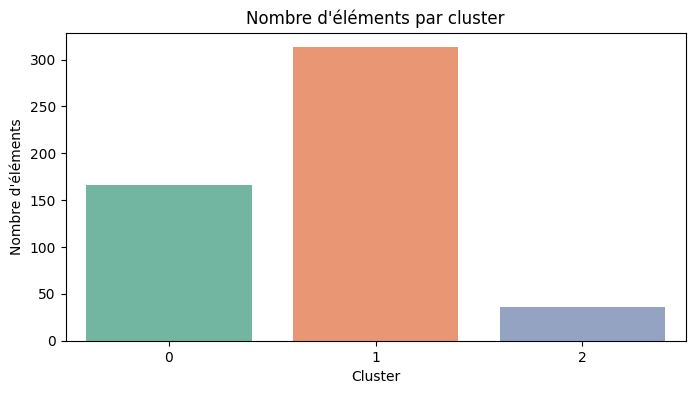

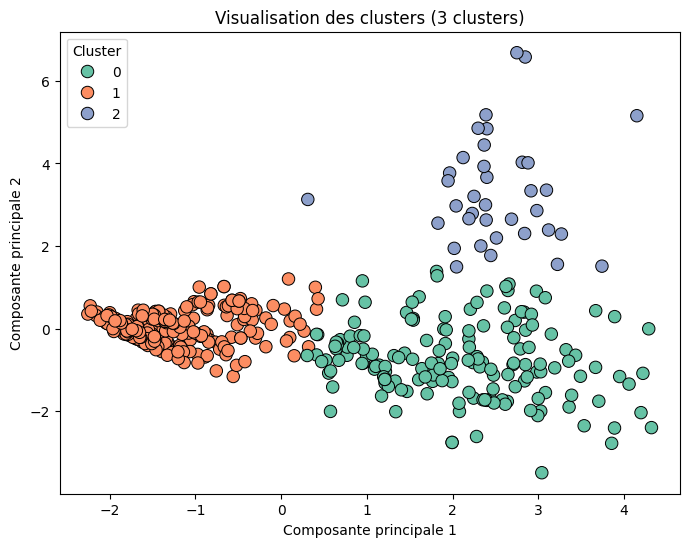

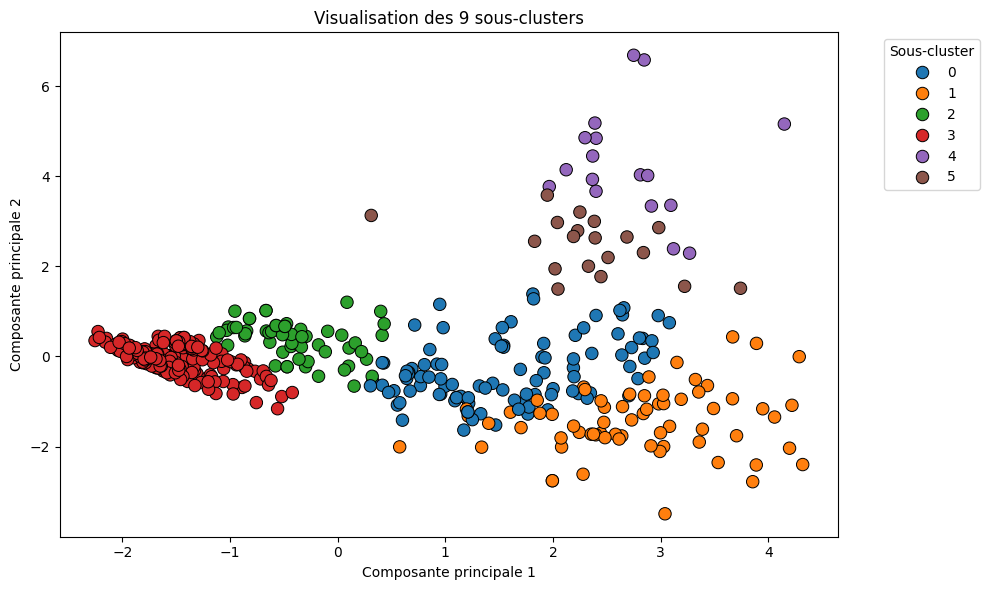

In [ ]:
# 5. Appliquer KMeans avec le k optimal
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Ajouter la colonne des clusters aux données initiales
df['Cluster'] = clusters

# 🔹 Affichage des effectifs par cluster avec Seaborn
plt.figure(figsize=(8, 4))
sns.countplot(x=df["Cluster"], palette="Set2")
plt.title("Nombre d'éléments par cluster")
plt.xlabel("Cluster")
plt.ylabel("Nombre d'éléments")
plt.show()

# 6. Visualisation des clusters avec PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['Cluster'], palette='Set2', s=80, edgecolor='black')
plt.title(f"Visualisation des clusters ({optimal_k} clusters)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Cluster")
plt.show()

"""
# 7. Affichage final : données avec labels et clusters triés par cluster
df_final = df.copy()
#df_final.insert(0, "Label", labels)  # Réintégrer les labels au début
df_final = df_final.sort_values(by="Cluster")  # Trier par cluster

# 🔹 Affichage du tableau final trié par cluster
display(df_final.head(50).style.background_gradient(cmap="coolwarm").set_caption("📌 Données triées par cluster"))
plt.show()
"""

# 1. Appliquer KMeans initial (déjà fait)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)
df['Cluster'] = clusters

# 2. Créer une nouvelle colonne pour les sous-clusters
df['SubCluster'] = -1

# 3. Appliquer KMeans dans chaque cluster séparément
for cluster_id in df['Cluster'].unique():
    # Récupérer les indices de ce cluster
    idx = df[df['Cluster'] == cluster_id].index
    # Extraire les données correspondantes
    X_cluster = df_scaled[idx]
    # Appliquer un nouveau KMeans sur ce sous-ensemble
    sub_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    sub_clusters = sub_kmeans.fit_predict(X_cluster)
    # Enregistrer les sous-clusters
    df.loc[idx, 'SubCluster'] = sub_clusters + cluster_id * 2  # Pour avoir des sous-clusters uniques (0 à 8)

# 4. PCA pour la visualisation
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# 5. Affichage des sous-clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['SubCluster'], palette='tab10', s=80, edgecolor='black')
plt.title("Visualisation des 6 sous-clusters")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Sous-cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



C:\Users\bertr\AppData\Local\Temp\ipykernel_7312\2215911251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Cluster"], palette="Set2")


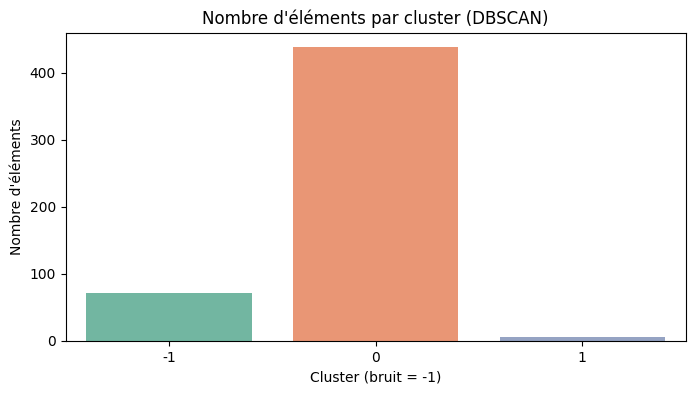

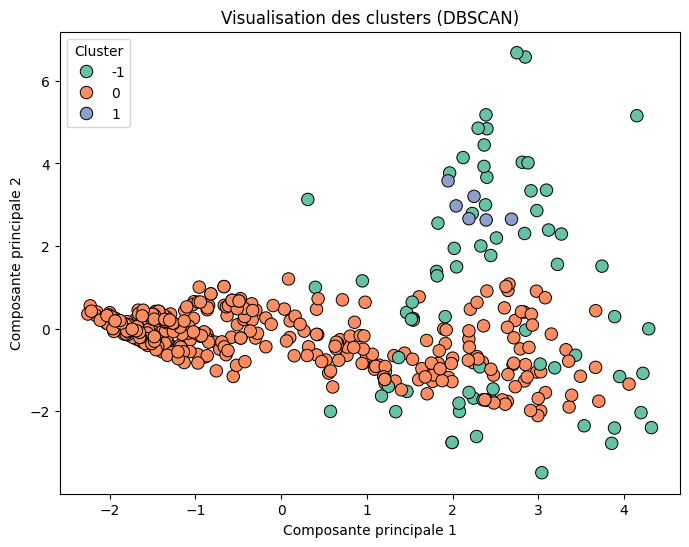

'\n# 6. 🔹 Affichage final trié\ndf_final = df.sort_values(by="Cluster")\ndisplay(df_final.head(50).style.background_gradient(cmap="coolwarm").set_caption("📌 Données triées par cluster (DBSCAN)"))\n'

In [25]:
# 2. DBSCAN : epsilon (rayon) et min_samples sont à ajuster
dbscan = DBSCAN(eps=1, min_samples=5)  # ajuster si besoin
clusters = dbscan.fit_predict(df_scaled)

# 3. Ajouter les clusters aux données
df['Cluster'] = clusters

# 4. 🔹 Affichage des effectifs
plt.figure(figsize=(8, 4))
sns.countplot(x=df["Cluster"], palette="Set2")
plt.title("Nombre d'éléments par cluster (DBSCAN)")
plt.xlabel("Cluster (bruit = -1)")
plt.ylabel("Nombre d'éléments")
plt.show()

# 5. PCA pour visualisation
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['Cluster'], palette="Set2", s=80, edgecolor='black')
plt.title("Visualisation des clusters (DBSCAN)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Cluster")
plt.show()

"""
# 6. 🔹 Affichage final trié
df_final = df.sort_values(by="Cluster")
display(df_final.head(50).style.background_gradient(cmap="coolwarm").set_caption("📌 Données triées par cluster (DBSCAN)"))
"""



c:\Users\bertr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


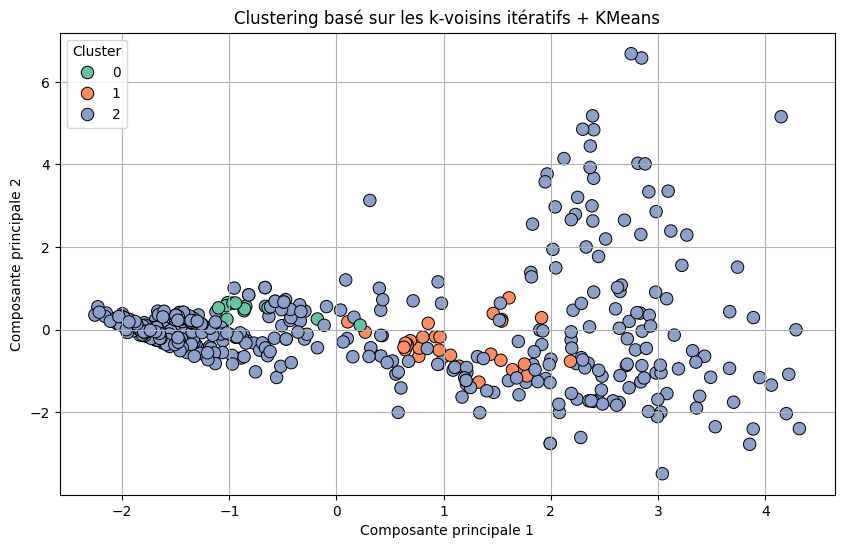

In [20]:
import numpy as np
from sklearn.metrics import pairwise_distances

class IterativeNeighborhood:
    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X):
        self.X = X
        self.distances = pairwise_distances(X, metric=self.metric)
        self.neighborhoods = []

        for i in range(len(X)):
            V = [i]  # Démarre avec le point lui-même
            for _ in range(1, self.k):  # Ajouter jusqu'à k voisins
                remaining = list(set(range(len(X))) - set(V))
                closest_idx = min(remaining, key=lambda idx: np.min(self.distances[idx, V]))
                V.append(closest_idx)
            self.neighborhoods.append(V)
        return self

    def get_neighborhoods(self):
        return self.neighborhoods


from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Récupère les voisinages
model = IterativeNeighborhood(k=5)
model.fit(df_scaled)
neighborhoods = model.get_neighborhoods()

# 2. Créer une représentation binaire (matrice de similarité)
n = len(df_scaled)
neighbor_matrix = np.zeros((n, n))

for i, neigh in enumerate(neighborhoods):
    for j in neigh:
        neighbor_matrix[i, j] = 1  # 1 si j est dans les k voisins de i

# 3. Clustering sur la matrice binaire
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(neighbor_matrix)

# 4. PCA pour visualisation
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

df_plot = pd.DataFrame(pca_result, columns=["PCA1", "PCA2"])
df_plot["Cluster"] = clusters

# 5. Affichage
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=80, edgecolor="black")
plt.title("Clustering basé sur les k-voisins itératifs + KMeans")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()



C:\Users\bertr\AppData\Local\Temp\ipykernel_7312\4093461118.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pca_weights.index, x=pca_weights["PCA1"], ax=axes[0], palette="coolwarm")
C:\Users\bertr\AppData\Local\Temp\ipykernel_7312\4093461118.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pca_weights.index, x=pca_weights["PCA2"], ax=axes[1], palette="coolwarm")
C:\Users\bertr\AppData\Local\Temp\ipykernel_7312\4093461118.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=variable_importance.index, x=variable_importance.value

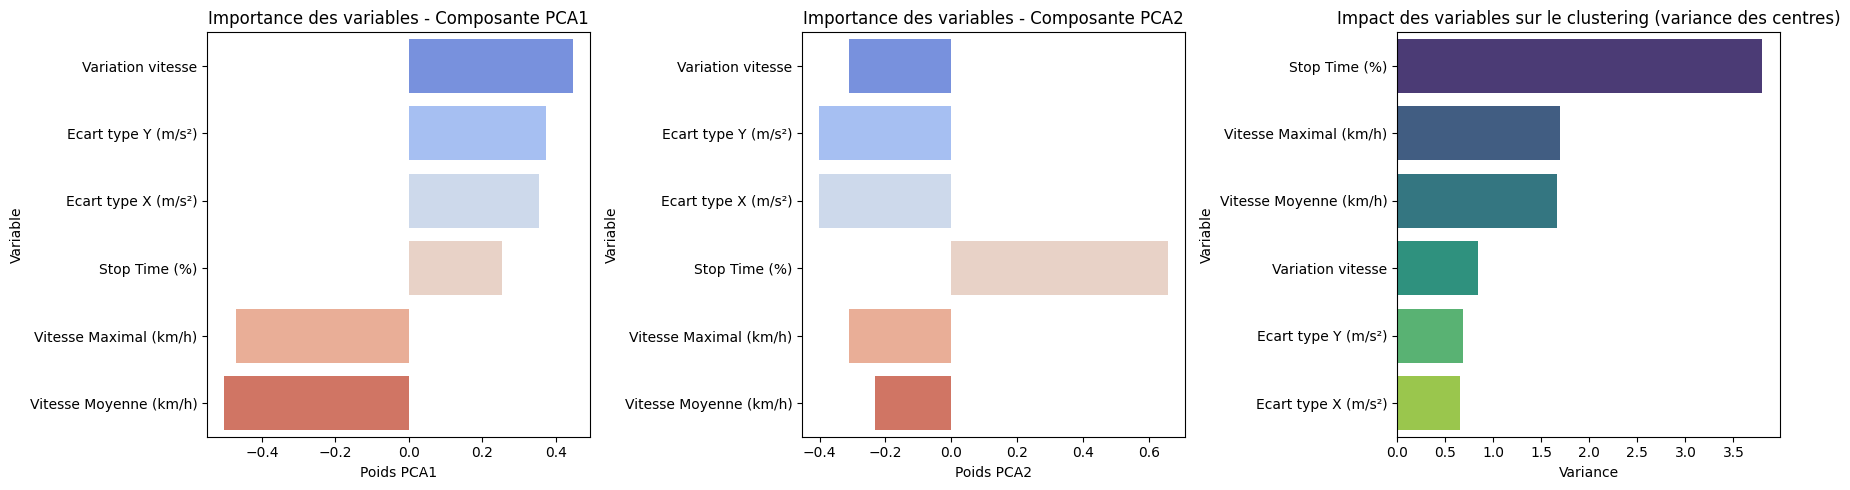

In [9]:
# 🔹 1. Importance des variables avec PCA (Composantes 1 et 2)
pca_full = PCA(n_components=len(df_numeric.columns))
pca_full.fit(df_scaled)

# Extraction des poids pour les 2 premières composantes principales
pca_weights = pd.DataFrame(
    pca_full.components_[:2].T,  # On prend PCA1 et PCA2
    index=df_numeric.columns,
    columns=["PCA1", "PCA2"]
).sort_values(by="PCA1", ascending=False)

# 🔹 2. Impact des variables sur les clusters (variance des centres)
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=df_numeric.columns)
variable_importance = cluster_centers.var().sort_values(ascending=False)

# 🔹 3. Affichage des résultats
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA - Importance des variables pour la 1ère composante
sns.barplot(y=pca_weights.index, x=pca_weights["PCA1"], ax=axes[0], palette="coolwarm")
axes[0].set_title("Importance des variables - Composante PCA1")
axes[0].set_xlabel("Poids PCA1")
axes[0].set_ylabel("Variable")

# PCA - Importance des variables pour la 2ème composante
sns.barplot(y=pca_weights.index, x=pca_weights["PCA2"], ax=axes[1], palette="coolwarm")
axes[1].set_title("Importance des variables - Composante PCA2")
axes[1].set_xlabel("Poids PCA2")
axes[1].set_ylabel("Variable")

# Variance des centres de clusters
sns.barplot(y=variable_importance.index, x=variable_importance.values, ax=axes[2], palette="viridis")
axes[2].set_title("Impact des variables sur le clustering (variance des centres)")
axes[2].set_xlabel("Variance")
axes[2].set_ylabel("Variable")

plt.tight_layout()
plt.show()
